<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [2]:
import pandas as pd


In [3]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [4]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [6]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [7]:
target = pd.read_pickle( target_url )
type(target)


list

In [8]:
image_url = ''

### Library Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import urllib.request
import cv2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

## Load the Pickled Data

In [10]:
# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url)) # Convert list to numpy array for easier indexing

#### Checking Target Size and Shape

In [28]:
# For the 500-image subset:

print(f"y_subset size: {y_subset.size}")
print(f"y_subset shape: {y_subset.shape}")

# Or for the full dataset (y_full):

print(f"y_full size: {y_full.size}")
print(f"y_full shape: {y_full.shape}")

y_subset size: 500
y_subset shape: (500,)
y_full size: 24946
y_full shape: (24946,)


#### Check the Dimensions of the Numpy Array

In [24]:
# Check dimensions of the feature images (X_full) and target labels (y_full)

print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")

X_full shape: (24946, 100, 100, 1)
y_full shape: (24946,)


### Get Length of X_full

In [29]:
# Get the length of X_full

print(len(X_full))

24946


### Subsample for Pass 1 (500 images, randomized)

In [44]:
# Subsample for Pass 1 (500 images, randomized)

np.random.seed(42) # For reproducibility
indices = np.arange(len(X_full))
np.random.shuffle(indices)

subset_indices = indices[:500]
X_subset = X_full[subset_indices] # images
y_subset = y_full[subset_indices] # target

In [45]:
# Print indices

indices

array([22802,  3617, 10941, ...,   860, 15795, 23654])

In [46]:
# Print X_subset

X_subset

array([[[[110],
         [111],
         [108],
         ...,
         [ 81],
         [ 78],
         [ 74]],

        [[103],
         [105],
         [106],
         ...,
         [ 89],
         [ 82],
         [ 79]],

        [[112],
         [112],
         [112],
         ...,
         [104],
         [ 93],
         [ 89]],

        ...,

        [[ 79],
         [ 76],
         [ 83],
         ...,
         [ 30],
         [ 38],
         [ 37]],

        [[ 88],
         [ 89],
         [ 87],
         ...,
         [ 34],
         [ 36],
         [ 35]],

        [[ 97],
         [ 95],
         [ 92],
         ...,
         [ 25],
         [ 41],
         [ 40]]],


       [[[167],
         [166],
         [168],
         ...,
         [212],
         [203],
         [195]],

        [[144],
         [150],
         [148],
         ...,
         [203],
         [206],
         [205]],

        [[160],
         [163],
         [164],
         ...,
         [195],
         [

In [47]:
# Print y_subset

y_subset

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,

In [12]:
# Data Cleaning (Scaling)

X_subset = X_subset / 255.0
X_subset

array([[[[0.43137255],
         [0.43529412],
         [0.42352941],
         ...,
         [0.31764706],
         [0.30588235],
         [0.29019608]],

        [[0.40392157],
         [0.41176471],
         [0.41568627],
         ...,
         [0.34901961],
         [0.32156863],
         [0.30980392]],

        [[0.43921569],
         [0.43921569],
         [0.43921569],
         ...,
         [0.40784314],
         [0.36470588],
         [0.34901961]],

        ...,

        [[0.30980392],
         [0.29803922],
         [0.3254902 ],
         ...,
         [0.11764706],
         [0.14901961],
         [0.14509804]],

        [[0.34509804],
         [0.34901961],
         [0.34117647],
         ...,
         [0.13333333],
         [0.14117647],
         [0.1372549 ]],

        [[0.38039216],
         [0.37254902],
         [0.36078431],
         ...,
         [0.09803922],
         [0.16078431],
         [0.15686275]]],


       [[[0.65490196],
         [0.65098039],
         [0.65

## Exploratory Data Analysis (EDA)

### Check Data Type & Structure

In [25]:
# Check type and length

print(f"Type: {type(y_full)}")
print(f"Total samples: {len(y_full)}")

# Inspect the first 10 labels

print(f"First 10 labels: {y_full[:10]}")

Type: <class 'numpy.ndarray'>
Total samples: 24946
First 10 labels: [0 1 1 0 0 0 0 0 0 0]


In [26]:
# Using numpy to count occurrences

unique_labels, counts = np.unique(y_full, return_counts=True)

for label, count in zip(unique_labels, counts):
    class_name = "Cat" if label == 1 else "Dog"
    percentage = (count / len(y_full)) * 100
    print(f"Label {label} ({class_name}): {count} images ({percentage:.1f}%)")

Label 0 (Dog): 12470 images (50.0%)
Label 1 (Cat): 12476 images (50.0%)


In [27]:
# Check Unique Values and Data Type

print(f"Data type: {y_full.dtype}")
print(f"Unique values: {np.unique(y_full)}")

Data type: int64
Unique values: [0 1]


In [13]:
# Verifying Dimensionality

print(f"X_subset shape: {X_subset.shape}")
print(f"y_subset shape: {y_subset.shape}")

X_subset shape: (500, 100, 100, 1)
y_subset shape: (500,)


#### Checking Class Distribution: Is the Dataset Balanced or Unbalanced? (# Cats vs # Dogs)

In [22]:
# using np.unique to get percentages directly

unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    class_name = "Cat" if label == 1 else "Dog"
    print(f"{class_name} ({label}): {count} ({count / len(y_subset):.1%})")

Dog (0): 248 (49.6%)
Cat (1): 252 (50.4%)


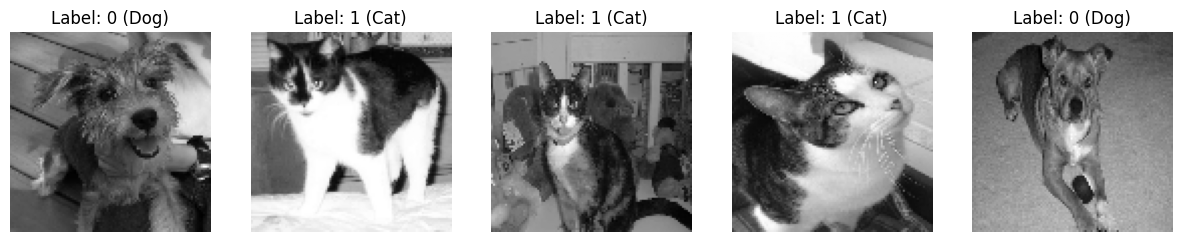

In [14]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)

    # X_subset is (500, 100, 100, 1), we reshape to (100, 100) for visualization

    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Cat" if y_subset[i] == 1 else "Dog"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

###

## CNN Architecture & Compilation

## Train Test Split

In [15]:
# Here, I define the deep learning architecture using Keras Sequential layers, featuring two Conv2D and MaxPooling2D blocks

# Train-Test Split (80/20 split)

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

In [16]:
# Build the Sequential Model

model = Sequential()
model

<Sequential name=sequential, built=False>

In [17]:
# Adding Convolutional Blocks

# Block 1

model.add(Input(shape=(100, 100, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [18]:
# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [19]:
# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training & Prediction

### Model Fitting

In [50]:
# Fit the Model

history = model.fit(X_train, y_train, epochs=6, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.6000 - val_loss: 1.5418
Epoch 2/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 0.5400 - val_loss: 1.5847
Epoch 3/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 490ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.5500 - val_loss: 1.6144
Epoch 4/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 485ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.5800 - val_loss: 1.6266
Epoch 5/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.5600 - val_loss: 1.6606
Epoch 6/6
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 374ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.5700 - val_loss: 1.6794


#### Plot Training & Validation Metrics

- Model Loss Plot
    - The Train Loss drops close to 0 immediately, while the Validation Loss starts high (~1.5) and keeps climbing upward. This huge gap means the model is memorizing the training data rather than learning actual general features of cats and dogs.

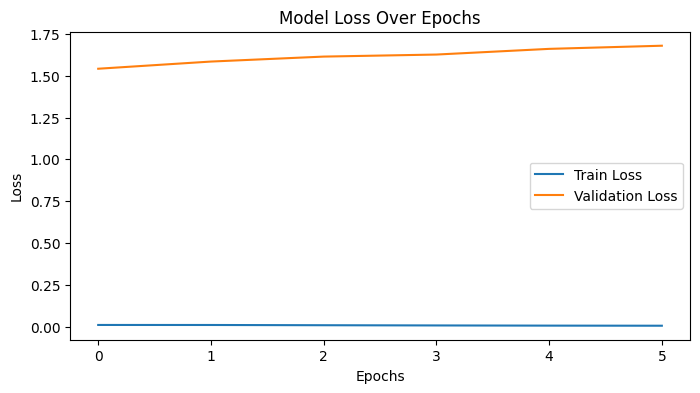

In [52]:
# Plot Training & Validation Loss

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

- Model Accuracy Plot
  - The Train Accuracy stays at a perfect 100% (1.0) across all epochs, while the Validation Accuracy hovers around 54–60%. Since random guessing on a two-class problem gives 50%, a validation score near 55% means the model is barely doing better than a coin flip on new, unseen images.

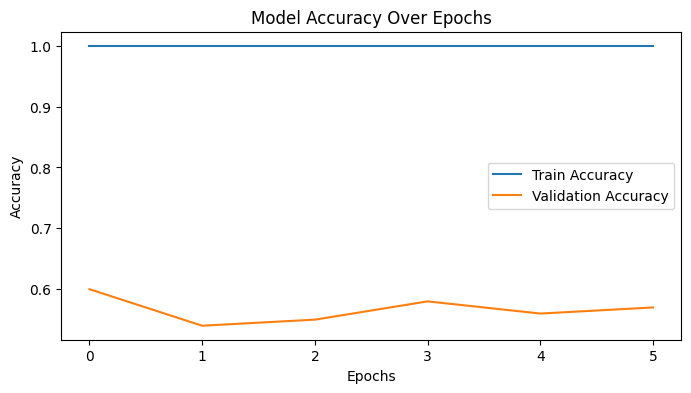

In [53]:
# Plot Training & Validation Accuracy

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### KEY TAKE AWAY:
- The model is suffering from severe overfitting. It learned the 400 training images perfectly, but because it only trained on a tiny sample size (500 images total), it fails to generalize to the validation set.

## Performance Evaluation

In [ ]:
# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5400 - loss: 0.7098 

Test Accuracy: 54.00%


### External Prediction Function

In [ ]:
def predict_external_image(image_url, current_model):

    # Download and read the image

    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    # Resize to 100x100 to match model input

    img_resized = cv2.resize(img, (100, 100))

    # Scale and reshape to 4D array (1, 100, 100, 1)

    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    # Predict

    prediction = current_model.predict(img_reshaped)[0][0]
    predicted_class = "Cat" if prediction > 0.5 else "Dog"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


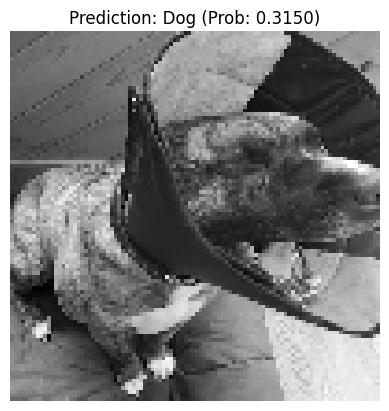

In [ ]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

### Pass 1 Analytical Review

#### Test Prediction

Extracting predictions and analyzing the probabilistic confidence of the network to answer your benchmark questions.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step 


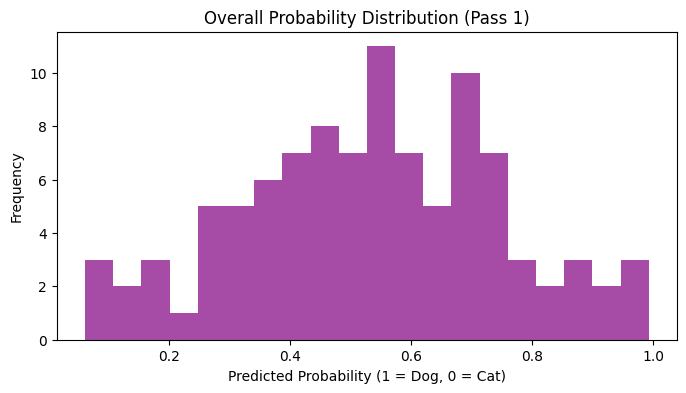

In [ ]:
# Generate predictions for the test set

test_predictions = model.predict(X_test)

# Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 1)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

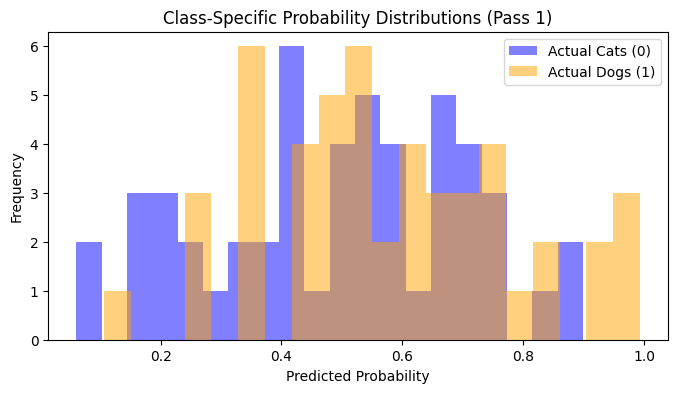

In [ ]:
# Class-Specific Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# High-Confidence False Positives (Predicted Cat, Actually Dog)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]
print(f"Number of high-confidence false cats: {len(false_cats)}")

# High-Confidence False Negatives (Predicted Dog, Actually Cat)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]
print(f"Number of high-confidence false dogs: {len(false_dogs)}")

Number of high-confidence false cats: 98
Number of high-confidence false dogs: 255


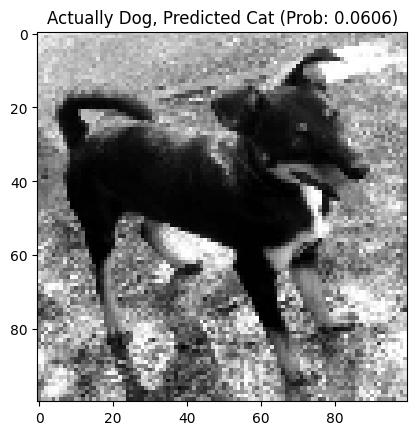

In [ ]:
# Visualizing Oddities (Plotting the errors)

if len(false_cats) > 0:
    plt.imshow(X_test[false_cats[0]].reshape(100, 100), cmap='gray')
    plt.title(f"Actually Dog, Predicted Cat (Prob: {test_predictions[false_cats[0]].item():.4f})")
    plt.show()

### Hyperparameter Experimentation

An example of an alternative architecture you can run right after baseline to see how node additions and activation function swaps alter training dynamics.

In [ ]:
# Experimental Model: Adding a layer, increasing nodes, changing activation to 'elu'

exp_model = Sequential()

# Add explicit Input layer

exp_model.add(Input(shape=(100, 100, 1)))

# Block 1

exp_model.add(Conv2D(64, kernel_size=(3, 3), activation='elu', input_shape=(100, 100, 1)))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model.add(Conv2D(128, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3 (New)

exp_model.add(Conv2D(128, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer

exp_model.add(Flatten())
exp_model.add(Dense(1, activation='sigmoid'))

exp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model

exp_history = exp_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5150 - loss: 0.7325 - val_accuracy: 0.4900 - val_loss: 0.7433
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5250 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5850 - loss: 0.6768 - val_accuracy: 0.5600 - val_loss: 0.6749
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6075 - loss: 0.6572 - val_accuracy: 0.5800 - val_loss: 0.6728
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6900 - loss: 0.6178 - val_accuracy: 0.5600 - val_loss: 0.6873
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7400 - loss: 0.5635 - val_accuracy: 0.6000 - val_loss: 0.6797
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7550 - loss: 0.5146 - val_accuracy: 0.6000 - val_loss: 0.7137
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8000 - loss: 0.4501 - val_accuracy: 0.5700 - val_loss: